<h2 style="color:blue"
align="center"> Decision Tree Classification</h2>

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:\\Users\\HP\\Desktop\\AIML\\Datasets\\salaries.csv")

In [3]:
df

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0
5,google,computer programmer,masters,1
6,abc pharma,sales executive,masters,0
7,abc pharma,computer programmer,bachelors,0
8,abc pharma,business manager,bachelors,0
9,abc pharma,business manager,masters,1


In [4]:
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [6]:
label_encoders = {}
for column in ["company", "job", "degree"]:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [9]:
X = df[["company", "job", "degree"]]
y = df["salary_more_then_100k"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [12]:
clf = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=42)

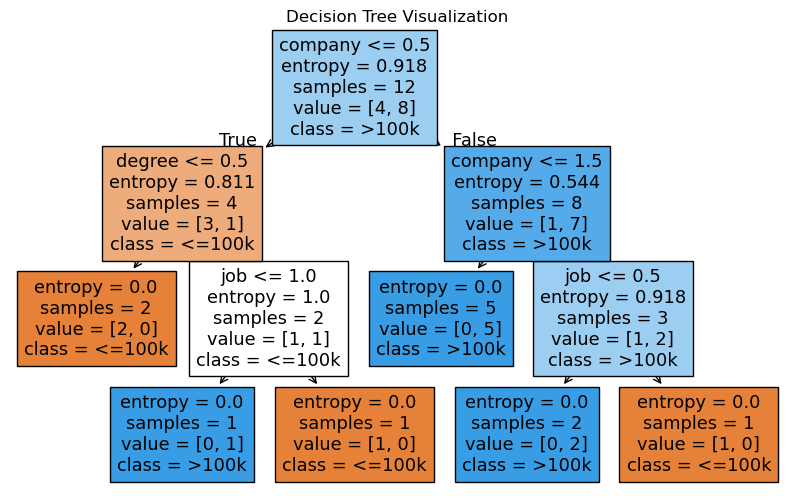

In [14]:
plt.figure(figsize=(10,6))
plot_tree(clf, feature_names=["company", "job", "degree"], class_names=["<=100k", ">100k"], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

In [15]:
tree_rules = export_text(clf, feature_names=["company", "job", "degree"])
print(tree_rules)

|--- company <= 0.50
|   |--- degree <= 0.50
|   |   |--- class: 0
|   |--- degree >  0.50
|   |   |--- job <= 1.00
|   |   |   |--- class: 1
|   |   |--- job >  1.00
|   |   |   |--- class: 0
|--- company >  0.50
|   |--- company <= 1.50
|   |   |--- class: 1
|   |--- company >  1.50
|   |   |--- job <= 0.50
|   |   |   |--- class: 1
|   |   |--- job >  0.50
|   |   |   |--- class: 0



In [16]:
new_data = [[0,1,1]]
prediction = clf.predict(new_data)
print(f"Predicted salary category: {'>100k' if prediction[0] == 1 else '<=100k'}")

Predicted salary category: >100k


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
